The code in this notebook was inspired and partially copied/derived from these articles:

https://towardsdatascience.com/lime-vs-shap-which-is-better-for-explaining-machine-learning-models-d68d8290bb16

LIME vs. SHAP: Which is Better for Explaining Machine Learning Models?
Two of the most popular Explainers compared
Dario Radečić, Dec 14, 2020

https://towardsdatascience.com/squeezing-more-out-of-lime-with-python-28f46f74ca8e
Squeezing More out of LIME with Python
How to create global aggregations of LIME weights
Conor O'Sullivan, May 4 2022

However many of the features do not work for MLP.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## **I chose the breast cancer Winconsin dataset from sklearn.datasets.**

In [2]:
%pip install -q numpy pandas scikit-learn
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

#Download breast cancer dataset as a DataFrame
raw_data = load_breast_cancer(as_frame=True)
breast_cancer_data = raw_data.frame

type(breast_cancer_data)

# Do not truncate columns when displaying null counts and value counts
pd.set_option('display.max_columns', None)

# Check for missing values and class distribution
print(breast_cancer_data.isnull().sum().sum())
print(breast_cancer_data['target'].value_counts())

# Display the first few rows of the dataset
breast_cancer_data.head()


Note: you may need to restart the kernel to use updated packages.
0
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<Axes: >

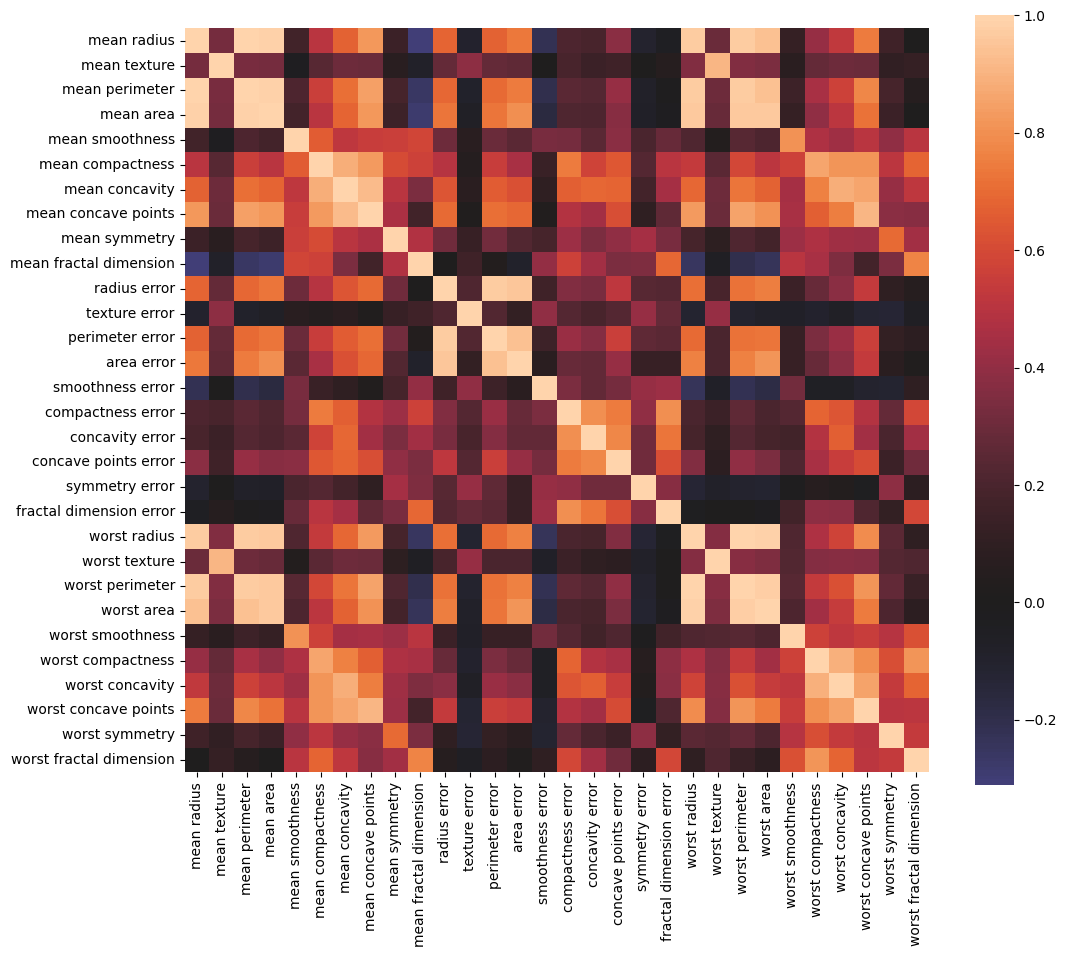

In [3]:
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

X = breast_cancer_data.drop('target', axis=1)
y = breast_cancer_data['target']

cormat = X.corr()

plt.figure(figsize=(12,10))
sns.heatmap(cormat, square=True, center=0)

### *4. Explore the data (it should only contain numerical variables), and create a correlation heatmap of the correlations of X.  You may choose to remove one or more highly correlated variables.  Justify your choices in writing.*

 ### **Data exploration revealed that the data only contained numerical variables. The correlation heatmap can be found in the output of cell 2. The heatmap shows that the strongest multicollinearity occurs between the mean and worst versions of the same features (mean/worst radius, perimeter, and area). This is expected because both measurements represent the expected physical properties of the tumor, with the worst value capturing extreme regions. Because an MLPClassifier is robust to correlated inputs, retaining all features allows the model to leverage both average and extreme tumor characteristics while preserving interpretability for LIME and SHAP analysis.**

In [4]:
#Split data set into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:

#Set the random number generation seed so that results can be duplicated
np.random.seed(12345)

#Fit a Neural Network model with the training data
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(30,30,30), activation='relu', solver='adam', max_iter=20000)
mlp.fit(X_train.values,y_train)



MLPClassifier(hidden_layer_sizes=(30, 30, 30), max_iter=20000)

In [6]:
from sklearn.metrics import classification_report
#Provide quality of fit metrics with the test dataset
y_pred = mlp.predict(X_test)
target_names = set(raw_data['target_names'])
print(X_test.columns)
print(classification_report(y_test, y_pred, target_names=target_names))

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')
              precision    recall  f1-score   support

      benign       0.98      0.93      0.95        43
   malignant       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



/Users/Russell/workspace/github.com/boot/asteroids/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


In [15]:
%pip install -q lime
import lime
from lime import lime_tabular

#install Lime

test_1 = X_test.iloc[14] # the instance to explain using LIME
print(test_1, y_pred[14])

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['malignant', 'benign'],
    mode='classification'
)

#Explain one instance of the data with lime
lime_exp = lime_explainer.explain_instance(
    data_row=test_1,
    predict_fn=mlp.predict_proba
)
lime_exp.show_in_notebook(show_table=True)

Note: you may need to restart the kernel to use updated packages.
mean radius                 12.340000
mean texture                12.270000
mean perimeter              78.940000
mean area                  468.500000
mean smoothness              0.090030
mean compactness             0.063070
mean concavity               0.029580
mean concave points          0.026470
mean symmetry                0.168900
mean fractal dimension       0.058080
radius error                 0.116600
texture error                0.495700
perimeter error              0.771400
area error                   8.955000
smoothness error             0.003681
compactness error            0.009169
concavity error              0.008732
concave points error         0.005740
symmetry error               0.011290
fractal dimension error      0.001366
worst radius                13.610000
worst texture               19.270000
worst perimeter             87.220000
worst area                 564.900000
worst smoothness      

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')
114


Text(0.5, 0, 'Mean |Weight|')

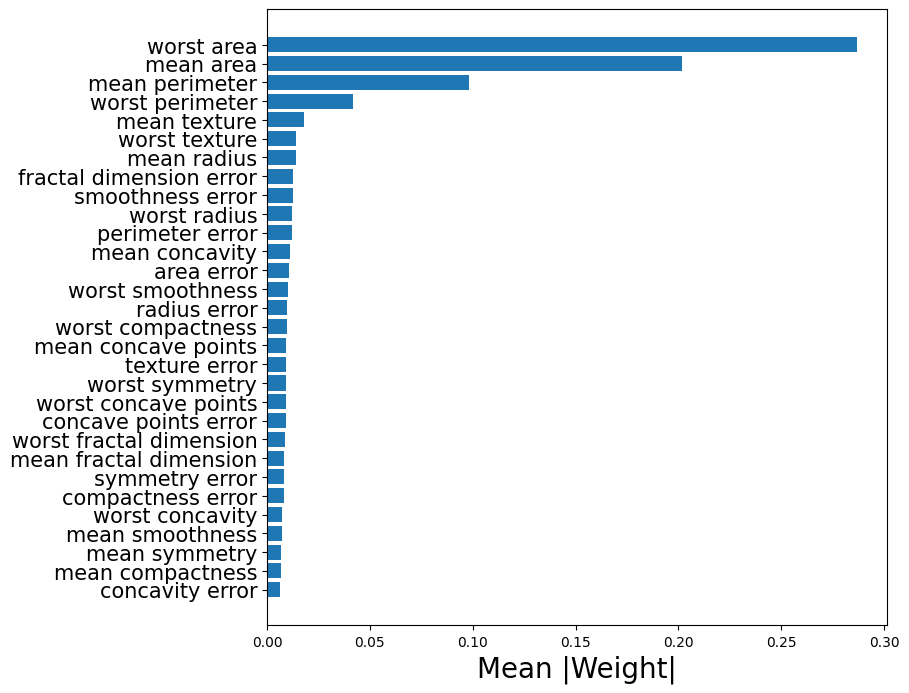

In [8]:
import matplotlib.pyplot as plt

weights = []

#Function to get weights from LIME explanation object
def return_weights(ep):
    exp_list = exp.as_map()[1] # benign
    exp_list = sorted(exp_list, key=lambda x: x[0])
    exp_weight = [x[1] for x in exp_list]
    return exp_weight

print(X_test.columns)
print(len(X_test))

#Iterate over the rows in feature matrix
#and collect the LIME weights
#You can run for more elements----but we pick a max of 25
for x in range(min(len(X_test),25)):
    #Get explanation
    exp = lime_explainer.explain_instance(X_test.iloc[x],
                                 mlp.predict_proba, num_features = len(X_test.columns))
    #Get weights
    exp_weight = return_weights(exp)
    weights.append(exp_weight)

#Create DataFrame of the LIME weights
lime_weights = pd.DataFrame(data=weights,columns=X_test.columns)

#Get absolute value of the mean of LIME weights
abs_mean = lime_weights.abs().mean(axis=0)
abs_mean = pd.DataFrame(data={'feature':abs_mean.index, 'abs_mean':abs_mean})
abs_mean = abs_mean.sort_values('abs_mean')

#Plot abs mean LIME weights
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(8,8))

y_ticks = range(len(abs_mean))
y_labels = abs_mean.feature
plt.barh(y=y_ticks,width=abs_mean.abs_mean)

plt.yticks(ticks=y_ticks,labels=y_labels,size= 15)
plt.title('')
plt.ylabel('')
plt.xlabel('Mean |Weight|',size=20)

In [9]:
# SHAP single instance explanation for class 0 (malignant)

%pip install -q shap
import shap
shap.initjs()
#Create a summary plot of the influence of all input variables on instance 15 of the test dataset
shap_explainer = shap.KernelExplainer(mlp.predict_proba, X_train)
shap_values = shap_explainer.shap_values(X_test.iloc[14,:])
shap.force_plot(shap_explainer.expected_value[0], shap_values[:, 0], X_test.iloc[14,:])

Note: you may need to restart the kernel to use updated packages.


Using 455 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [ ]:
# SHAP global explanation for class 1 (benign)

shap.initjs()
shap_values = shap_explainer.shap_values(X_test)
#Now we show an interactive plot for all values/samples in the dataset
#to tie out before you need original sample ordering on the x axis and
#"f(x)" on the y-axis and look at x=14 and you will see proline of 325
shap.force_plot(shap_explainer.expected_value[1], shap_values[:, :, 0], X_test, matplotlib=True)

  0%|          | 0/114 [00:00<?, ?it/s]

Using 455 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/114 [00:00<?, ?it/s]

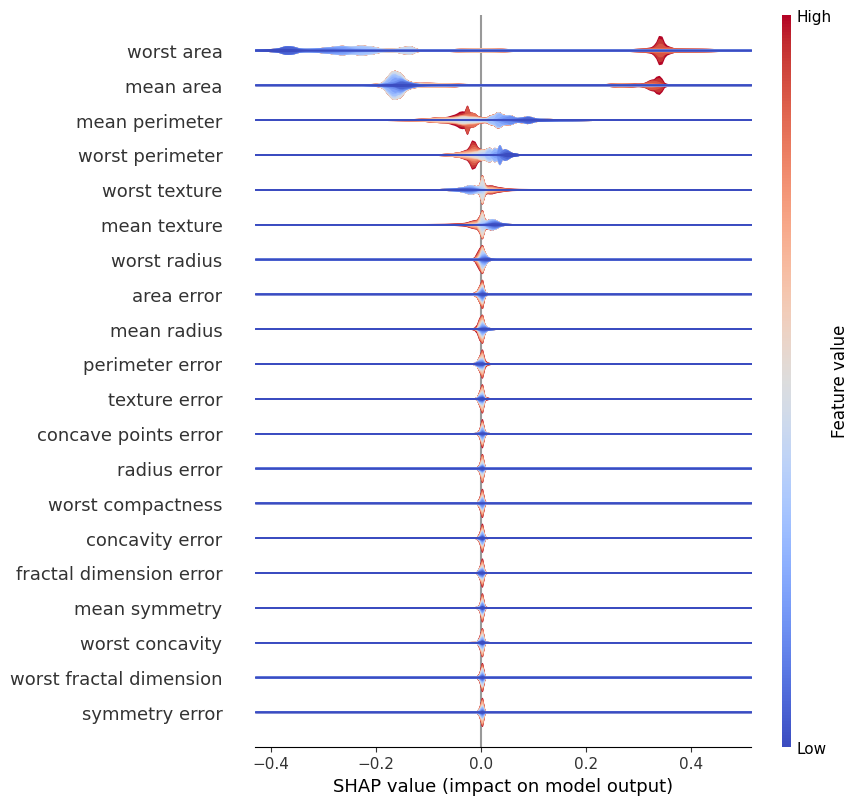

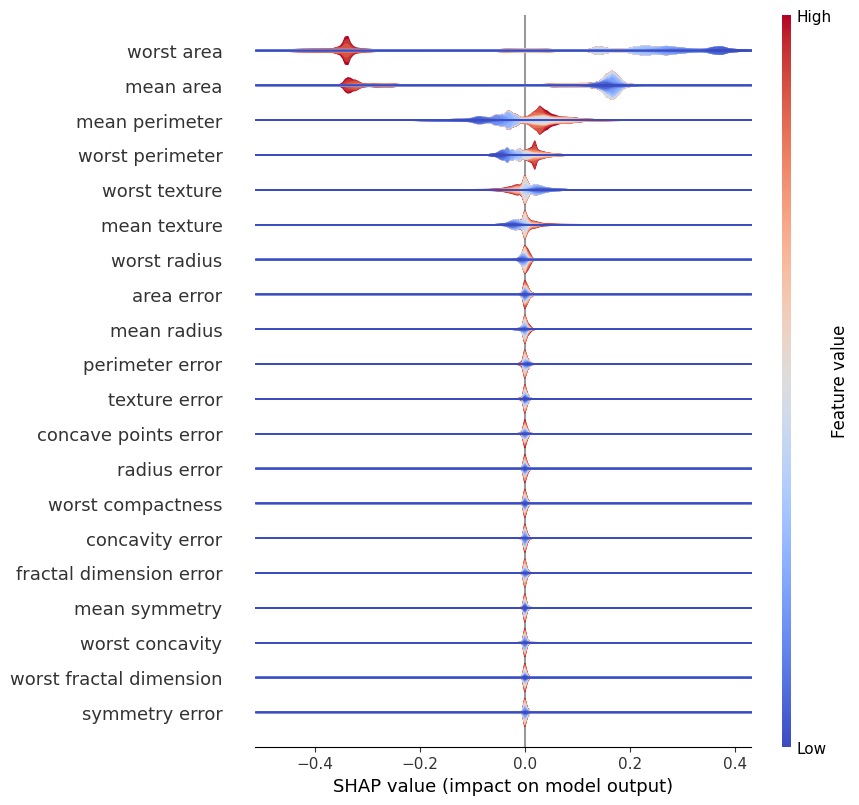

In [11]:
import warnings
warnings.filterwarnings("ignore")

shap.initjs()
#Create a summary plot of the influence of all input variables on the test dataset
shap_explainer = shap.KernelExplainer(mlp.predict_proba, X_train)

shap_vals = shap_explainer.shap_values(X_test)

feat_names = list(X_test.columns)
shap.plots.violin(shap_vals[:,:,0], features=X_test, feature_names=feat_names, plot_type="layered_violin") # label: malignant
shap.plots.violin(shap_vals[:,:,1], features=X_test, feature_names=feat_names, plot_type="layered_violin") # label: benign

